In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [38]:
df = pd.read_csv("Exam_Score_Prediction.csv")

In [39]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [40]:
df = df[['study_hours', 'exam_score']].copy()
df.head()

,study_hours,exam_score
0,2.78,58.9
1,3.37,54.8
2,7.88,90.3
3,0.67,29.7
4,0.89,43.7


In [47]:
df = df.rename(columns = {"study_hours": "studytime", "exam_score": "score"})
print(df)
df = df.sample(1000, random_state=42)

       studytime  score
0           2.78   58.9
1           3.37   54.8
2           7.88   90.3
3           0.67   29.7
4           0.89   43.7
...          ...    ...
19995       6.50   86.5
19996       3.71   60.9
19997       7.88   64.5
19998       4.60   79.0
19999       7.50   71.0

[20000 rows x 2 columns]


In [48]:
# calculate the loss for a given m and b
def calculate_loss(m :float, b :float, points: pd.DataFrame) -> float:
    total_loss = 0
    for i in range(len(points)):
        x = points.iloc[i].studytime
        y = points.iloc[i].score
        total_loss = total_loss + (y - (m*x +b))**2
    return total_loss / float(len(points))

In [49]:
sample_loss = calculate_loss(0.5, 0.5, df)
rmse = np.sqrt(sample_loss)
print(sample_loss)
print(rmse) 

3882.750018818004
62.31171654526943


In [50]:
def gradient_descent(m: float, b: float, points: pd.DataFrame, L: float) -> tuple[float, float]:
    m_gradient = 0
    b_gradient = 0

    n = len(points)
    for i in range(n):
        x = points.iloc[i].studytime
        y = points.iloc[i].score
        m_gradient += -(2/n) * x * (y - (m*x + b))
        b_gradient += -(2/n) * (y - (m*x + b))

    new_m = m - L * m_gradient
    new_b = b - L * b_gradient
    return new_m, new_b

In [51]:
def optimize(points: pd.DataFrame, m: float, b: float, L: float, num_iterations: int) -> tuple[float, float]:
    for i in range(num_iterations):
        if i % 100 == 0:
            print(f"Iteration {i}: m = {m}, b = {b}, loss = {np.sqrt(calculate_loss(m, b, points))}")
        m, b = gradient_descent(m, b, points, L)
    return m, b

In [52]:
m , b = optimize(df, 0.5, 0.5, 0.01, 1000)
print(m, b)

Iteration 0: m = 0.5, b = 0.5, loss = 62.31171654526943
Iteration 100: m = 10.078228428390743, b = 17.249898727172976, loss = 17.17432491320624
Iteration 200: m = 8.40962783799542, b = 25.946600503622886, loss = 14.666106819418962
Iteration 300: m = 7.40068500961751, b = 31.205183617159793, loss = 13.634345611451868
Iteration 400: m = 6.790613530082655, b = 34.38485989821349, loss = 13.237052866672599
Iteration 500: m = 6.421725224746042, b = 36.30749590757296, loss = 13.088785002810017
Iteration 600: m = 6.198671719740594, b = 37.470044826942974, loss = 13.034154459648324
Iteration 700: m = 6.063799279016781, b = 38.17299639101921, loss = 13.014123263741858
Iteration 800: m = 5.982246759739611, b = 38.598045946529496, loss = 13.006791783698189
Iteration 900: m = 5.93293488131018, b = 38.85505814178211, loss = 13.004110226048228
5.903117760076013 39.01046418244782


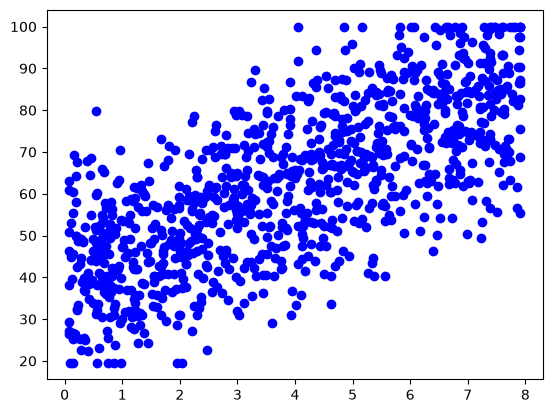

In [53]:
plt.scatter(df.studytime, df.score, color='blue', label='Data Points')

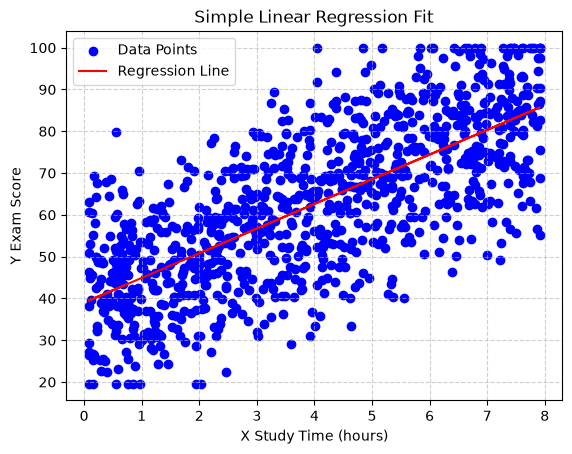

In [54]:
plt.scatter(df.studytime, df.score, color='blue', label='Data Points')
y_pred = m * df.studytime + b
plt.plot(df.studytime, y_pred, color='red', label='Regression Line')
plt.xlabel('X Study Time (hours)')
plt.ylabel('Y Exam Score')
plt.title('Simple Linear Regression Fit')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [55]:
rmse = np.sqrt(calculate_loss(m, b, df))
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 13.003129660529977
